# Shared model setup: splits + metrics

One shared definition of train/test split, CV folds, and evaluation
metrics, so 3 different models (built separately) stay comparable.

Each person then builds their own model in the "Your model here" section,
using the same `cv_folds`, `train_df` / `test_df`, and `regression_metrics`.


## 1. Load data

In [9]:
import numpy as np
import pandas as pd

DATA_PATH = r'..\data\model_input\df_model_input.csv'

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


(1745282, 80)


,report_date,lm_positive,lm_negative,lm_polarity,uncertainty_ratio,litigious_ratio,constraining_ratio,strong_modal_ratio,weak_modal_ratio,ifo_business_climate,...,log_toas,log_empl,ncliGrowthThisYear,toas_growth,cash_growth,growth_volatility,firm_age,years_in_panel,naics_2digit,is_na_empl
0,2013-12-01,420,652,-0.216418,0.016592,0.018863,0.011103,0.001009,0.004038,100.4,...,7.595447,0.000000,NaN,NaN,NaN,NaN,36.0,0,31,1
1,2014-12-01,265,402,-0.205397,0.020557,0.014647,0.003769,0.001970,0.006167,98.2,...,7.592642,0.000000,-0.034155,-0.002801,0.127094,NaN,37.0,1,31,1
2,2016-12-01,352,677,-0.315841,0.021990,0.012566,0.005463,0.002117,0.005600,101.0,...,7.514275,5.003946,-0.832512,-0.075375,-0.493523,0.564524,39.0,2,31,0
3,2017-12-01,397,547,-0.158898,0.016656,0.015763,0.006186,0.002141,0.004342,104.7,...,7.512180,4.718499,-0.093514,-0.002093,-0.112008,0.444788,40.0,3,31,0
4,2018-12-01,359,513,-0.176606,0.020424,0.012030,0.006295,0.002518,0.004337,101.2,...,7.472122,4.795791,-0.119000,-0.039266,-0.331663,0.419497,41.0,4,31,0


### 1.1 Count Missing Value

In [10]:
df = df.replace([np.inf, -np.inf], np.nan)
nan_summary = pd.DataFrame (
    {
        "NaN rows": df.isna().sum(),
        "% Missing": (df.isna().mean()*100).round(2),
    }
)
nan_summary = nan_summary[nan_summary["NaN rows"]>0].sort_values(by="NaN rows", ascending=False)
print(nan_summary)

                               NaN rows  % Missing
wkca                             680658      39.00
working_capital_ratio            680658      39.00
empl                             675543      38.71
cred                             665458      38.13
gearing                          662930      37.98
loan                             658999      37.76
growth_volatility                549276      31.47
ocli                             512417      29.36
quick_ratio                      512168      29.35
current_ratio                    494482      28.33
cash_growth                      315748      18.09
ncliGrowthThisYear               285318      16.35
toas_growth                      285318      16.35
de_consumer_confidence_growth    201605      11.55
firm_age                         129126       7.40
dateinc                          129126       7.40
cash                              63149       3.62
cash_ratio                        63149       3.62
tfas                           

### 1.2 Check Outlier

In [11]:
def outlier_report(df, cols, lower_pct=0.01, upper_pct=0.99):
    """Summarize outlier exposure per column using train-only percentiles."""
    rows = []
    for col in cols:
        s = df[col].dropna()
        if len(s) == 0:
            continue
        lo, hi = s.quantile([lower_pct, upper_pct])
        n_low = (s < lo).sum()
        n_high = (s > hi).sum()
        rows.append({
            "column": col,
            "skew": s.skew(),
            "min": s.min(),
            "p1": lo,
            "p50": s.median(),
            "p99": hi,
            "max": s.max(),
            "n_below_p1": n_low,
            "n_above_p99": n_high,
            "pct_flagged": (n_low + n_high) / len(s) * 100,
        })
    return pd.DataFrame(rows).sort_values("pct_flagged", ascending=False)

numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(
    ["ncliGrowthNextYear"]  # exclude target
)
report = outlier_report(df, numeric_cols)
report[report["pct_flagged"] > 0].round(3)

,column,skew,min,p1,p50,p99,max,n_below_p1,n_above_p99,pct_flagged
69,growth_volatility,0.752,0.000000e+00,0.004,0.279,9.320000e-01,1.413000e+00,11961,11961,2.000
54,wkca,352.379,-1.110000e+12,-897997.290,165.743,2.571511e+07,1.007681e+13,10647,10647,2.000
63,working_capital_ratio,1.245,-1.180000e-01,-0.118,0.069,8.530000e-01,8.530000e-01,10647,10647,2.000
59,quick_ratio,7.326,4.800000e-02,0.048,1.842,1.485751e+03,1.485753e+03,12332,12332,2.000
68,cash_growth,271.338,-1.222589e+04,-0.986,0.076,1.411920e+02,1.465824e+06,14296,14296,2.000
56,gearing,6.433,-2.231600e+01,-22.315,0.557,1.555510e+02,1.555620e+02,10824,10824,2.000
60,cash_ratio,1.194,0.000000e+00,0.000,0.124,8.330000e-01,8.330000e-01,16822,16822,2.000
67,toas_growth,831.605,-1.000000e+00,-0.483,0.042,3.082000e+00,1.377193e+07,14600,14600,2.000
66,ncliGrowthThisYear,-0.048,-1.000000e+00,-0.968,-0.040,9.070000e-01,1.000000e+00,14600,14600,2.000
44,osfd,607.777,-1.272615e+14,-2356765.030,450.275,5.939835e+07,2.596675e+14,17060,17060,2.000


### 1.3 Feature Engineering

In [12]:
import gc
YEAR_COL = "closdate_year"
ID_COL = "idnr"
def safe_ratio(
    numerator: pd.Series,
    denominator: pd.Series,
    *,
    require_positive_denominator: bool = True,
) -> pd.Series:
    numerator = pd.to_numeric(numerator, errors="coerce")
    denominator = pd.to_numeric(denominator, errors="coerce")
    valid = numerator.notna() & denominator.notna()
    if require_positive_denominator:
        valid &= denominator > 0
    else:
        valid &= denominator != 0
    out = pd.Series(np.nan, index=numerator.index, dtype="float32")
    out.loc[valid] = (numerator.loc[valid] / denominator.loc[valid]).astype("float32")
    return out.replace([np.inf, -np.inf], np.nan)

# Sort once so all lagged firm features use only t and earlier observations.
df = df.sort_values([ID_COL, YEAR_COL]).copy()
firm_group = df.groupby(ID_COL, sort=False)
lag_year = firm_group[YEAR_COL].shift(1)
consecutive = (df[YEAR_COL] - lag_year).eq(1)

# -----------------------------------------------------------------------------
# Ratios based on documented balance-sheet identities. No data-driven
# winsorization is used, so test-year values cannot influence training values.
# -----------------------------------------------------------------------------
if {"cuas", "culi"}.issubset(df.columns):
    df["current_ratio_clean"] = safe_ratio(df["cuas"], df["culi"])
    df["log1p_current_ratio_clean"] = np.log1p(
        df["current_ratio_clean"].clip(lower=0)
    ).astype("float32")

if {"cuas", "stok", "culi"}.issubset(df.columns):
    quick_assets = df["cuas"] - df["stok"]
    df["quick_ratio_clean"] = safe_ratio(quick_assets, df["culi"])
    df["log1p_quick_ratio_clean"] = np.log1p(
        df["quick_ratio_clean"].clip(lower=0)
    ).astype("float32")

if {"shfd", "toas"}.issubset(df.columns):
    df["solvency_ratio_clean"] = safe_ratio(df["shfd"], df["toas"])

if {"ncli", "loan", "shfd"}.issubset(df.columns):
    # Gearing is undefined or difficult to interpret with non-positive equity.
    gearing_num = df["ncli"] + df["loan"]
    df["gearing_ratio_clean"] = safe_ratio(gearing_num, df["shfd"])
    df["log1p_gearing_ratio_clean"] = np.log1p(
        df["gearing_ratio_clean"].clip(lower=0)
    ).astype("float32")

if {"ncli", "culi", "toas"}.issubset(df.columns):
    df["liabilities_to_assets"] = safe_ratio(df["ncli"] + df["culi"], df["toas"])

if {"wkca", "toas"}.issubset(df.columns):
    df["working_capital_to_assets"] = safe_ratio(
        df["wkca"], df["toas"], require_positive_denominator=True
    )

if {"stok", "cuas"}.issubset(df.columns):
    valid = (df["cuas"] > 0) & (df["stok"] >= 0) & (df["stok"] <= df["cuas"])
    df["inventory_share_current_assets"] = np.where(
        valid, df["stok"] / df["cuas"], np.nan
    ).astype("float32")

if {"debt", "cuas"}.issubset(df.columns):
    valid = (df["cuas"] > 0) & (df["debt"] >= 0) & (df["debt"] <= df["cuas"])
    df["receivables_share_current_assets"] = np.where(
        valid, df["debt"] / df["cuas"], np.nan
    ).astype("float32")

if {"cash", "toas"}.issubset(df.columns):
    valid = (df["toas"] > 0) & (df["cash"] >= 0) & (df["cash"] <= df["toas"])
    df["cash_to_assets"] = np.where(valid, df["cash"] / df["toas"], np.nan).astype("float32")

if {"fias", "toas"}.issubset(df.columns):
    valid = (df["toas"] > 0) & (df["fias"] >= 0) & (df["fias"] <= df["toas"])
    df["fixed_assets_share"] = np.where(valid, df["fias"] / df["toas"], np.nan).astype("float32")

if {"ltdb", "ncli"}.issubset(df.columns):
    valid = (df["ncli"] > 0) & (df["ltdb"] >= 0) & (df["ltdb"] <= df["ncli"])
    df["ltdb_share_of_ncli"] = np.where(valid, df["ltdb"] / df["ncli"], np.nan).astype("float32")

# -----------------------------------------------------------------------------
# Stable changes in firm levels. These replace unstable cash percentage growth
# and make the time direction explicit.
# -----------------------------------------------------------------------------
if "log_toas" not in df.columns and "toas" in df.columns:
    df["log_toas"] = np.log1p(df["toas"].clip(lower=0)).astype("float32")
if "log_empl" not in df.columns and "empl" in df.columns:
    df["log_empl"] = np.log1p(df["empl"].clip(lower=0)).astype("float32")

if "log_toas" in df.columns:
    lag_log_toas = firm_group["log_toas"].shift(1)
    df["log_toas_change_clean"] = np.where(
        consecutive, df["log_toas"] - lag_log_toas, np.nan
    ).astype("float32")

if {"cash", "toas"}.issubset(df.columns):
    lag_cash = firm_group["cash"].shift(1)
    lag_toas = firm_group["toas"].shift(1)
    valid = consecutive & lag_toas.gt(0)
    df["cash_change_to_lagged_assets"] = np.where(
        valid, (df["cash"] - lag_cash) / lag_toas, np.nan
    ).astype("float32")

if "ncliGrowthThisYear" in df.columns:
    rolling_volatility = (
        df.groupby(ID_COL, sort=False)["ncliGrowthThisYear"]
          .rolling(window=3, min_periods=2)
          .std()
          .reset_index(level=0, drop=True)
    )
    df["ncli_growth_volatility_3y"] = rolling_volatility.astype("float32")

# -----------------------------------------------------------------------------
# Macro transformations.
# Confidence balances can cross zero, so use first differences.
# Positive indices use percentage changes calculated from annual levels.
# -----------------------------------------------------------------------------
BALANCE_LEVELS = [
    "de_construction_confidence",
    "de_consumer_confidence",
    "de_industry_confidence",
    "de_retail_confidence",
    "de_services_confidence",
]
POSITIVE_INDEX_LEVELS = [
    "de_economic_sentiment_index",
    "de_employment_expectations_index",
    "ifo_business_climate",
    "ifo_business_expectations",
    "ifo_business_situation",
]

available_macro_levels = [
    c for c in BALANCE_LEVELS + POSITIVE_INDEX_LEVELS if c in df.columns
]
if available_macro_levels:
    annual_macro = (
        df.groupby(YEAR_COL, sort=True)[available_macro_levels]
          .median(numeric_only=True)
          .sort_index()
    )

    for col in [c for c in BALANCE_LEVELS if c in annual_macro.columns]:
        new_col = f"{col}_change_clean"
        year_values = annual_macro[col].diff()
        df[new_col] = df[YEAR_COL].map(year_values).astype("float32")

    for col in [c for c in POSITIVE_INDEX_LEVELS if c in annual_macro.columns]:
        new_col = f"{col}_pct_change_clean"
        current = annual_macro[col]
        previous = current.shift(1)
        year_values = ((current / previous) - 1).where((current > 0) & (previous > 0))
        df[new_col] = df[YEAR_COL].map(year_values).astype("float32")

# -----------------------------------------------------------------------------
# Text counts are used only if a document-length variable exists. Otherwise,
# raw lm_positive/lm_negative counts are omitted and polarity/ratios are used.
# -----------------------------------------------------------------------------
TOKEN_COUNT_CANDIDATES = [
    "token_count", "n_tokens", "word_count", "total_words", "document_length"
]
token_count_col = next((c for c in TOKEN_COUNT_CANDIDATES if c in df.columns), None)
if token_count_col is not None:
    for source, target in [
        ("lm_positive", "lm_positive_frequency"),
        ("lm_negative", "lm_negative_frequency"),
    ]:
        if source in df.columns:
            df[target] = safe_ratio(df[source], df[token_count_col])
    print(f"Normalized sentiment counts using: {token_count_col}")
else:
    print("No document-length column found: raw positive/negative counts will be omitted.")

# Replace any remaining infinities and downcast new floating-point columns.
float64_cols = df.select_dtypes(include="float64").columns
df[float64_cols] = df[float64_cols].astype("float32")
df.replace([np.inf, -np.inf], np.nan, inplace=True)

del firm_group, lag_year, consecutive
gc.collect()

No document-length column found: raw positive/negative counts will be omitted.


0

## 2. Config


In [13]:
df['report_year'] = pd.to_datetime(df['report_date']).dt.year
df.drop(columns=['report_date'], inplace=True)
df.head(5)

,lm_positive,lm_negative,lm_polarity,uncertainty_ratio,litigious_ratio,constraining_ratio,strong_modal_ratio,weak_modal_ratio,ifo_business_climate,ifo_business_situation,...,de_consumer_confidence_change_clean,de_industry_confidence_change_clean,de_retail_confidence_change_clean,de_services_confidence_change_clean,de_economic_sentiment_index_pct_change_clean,de_employment_expectations_index_pct_change_clean,ifo_business_climate_pct_change_clean,ifo_business_expectations_pct_change_clean,ifo_business_situation_pct_change_clean,report_year
0,420,652,-0.216418,0.016592,0.018863,0.011103,0.001009,0.004038,100.400002,99.099998,...,5.4,10.6,9.5,4.6,0.081466,0.011550,0.052411,0.068277,0.035528,2013
1,265,402,-0.205397,0.020557,0.014647,0.003769,0.001970,0.006167,98.199997,98.400002,...,-0.1,-4.7,-5.0,-2.4,-0.030132,-0.028544,-0.021912,-0.035398,-0.007064,2014
2,352,677,-0.315841,0.021990,0.012566,0.005463,0.002117,0.005600,101.000000,101.800003,...,1.5,5.5,-1.5,0.7,0.028195,0.020947,0.002979,-0.005952,0.011928,2016
3,397,547,-0.158898,0.016656,0.015763,0.006186,0.002141,0.004342,104.699997,107.099998,...,1.7,12.0,4.1,1.2,0.050274,0.042819,0.036634,0.022954,0.052063,2017
4,359,513,-0.176606,0.020424,0.012030,0.006295,0.002518,0.004337,101.199997,105.300003,...,-2.2,-10.6,-5.1,0.1,-0.040905,-0.010265,-0.033429,-0.050732,-0.016807,2018


In [14]:
MIN_TRAIN_YEARS = 5     # first fold: train on this many years, test on the next
TEST_YEARS = [2020, 2021, 2022, 2023]  

In [15]:
YEAR_COL = "report_year"          
TARGET   = "ncliGrowthNextYear"  

def present(columns: list[str]) -> list[str]:
    return [c for c in columns if c in df.columns]

CATEGORY_COLS = present(["naics_2digit", "type"])

FIRM_NUMERIC_CANDIDATES = [
    "log_toas",
    "log_empl",                 # raw empl is intentionally omitted
    "firm_age",
    "years_in_panel",
    "is_na_empl",
    "ncliGrowthThisYear",
    "log_toas_change_clean",
    "cash_change_to_lagged_assets",
    "ncli_growth_volatility_3y",
    "log1p_current_ratio_clean",
    "log1p_quick_ratio_clean",
    "solvency_ratio_clean",
    "log1p_gearing_ratio_clean",
    "liabilities_to_assets",
    "working_capital_to_assets",
    "inventory_share_current_assets",
    "receivables_share_current_assets",
    "cash_to_assets",
    "fixed_assets_share",
    "ltdb_share_of_ncli",
]
FIRM_FEATURES = present(FIRM_NUMERIC_CANDIDATES) + CATEGORY_COLS

SURVEY_LEVEL_FEATURES = present(BALANCE_LEVELS + POSITIVE_INDEX_LEVELS)
SURVEY_CHANGE_FEATURES = present(
    [f"{c}_change_clean" for c in BALANCE_LEVELS]
    + [f"{c}_pct_change_clean" for c in POSITIVE_INDEX_LEVELS]
)
SURVEY_FEATURES = SURVEY_LEVEL_FEATURES + SURVEY_CHANGE_FEATURES

TEXT_FEATURES = present([
    "lm_polarity",
    "uncertainty_ratio",
    "litigious_ratio",
    "constraining_ratio",
    "strong_modal_ratio",
    "weak_modal_ratio",
    "lm_positive_frequency",
    "lm_negative_frequency",
])

FEATURE_SETS = {
    "firm": FIRM_FEATURES,
    "firm_survey": list(dict.fromkeys(FIRM_FEATURES + SURVEY_FEATURES)),
    "firm_survey_text": list(dict.fromkeys(FIRM_FEATURES + SURVEY_FEATURES + TEXT_FEATURES)),
}

ALL_FEATURES = list(dict.fromkeys(FIRM_FEATURES + SURVEY_FEATURES + TEXT_FEATURES))

for name, cols in FEATURE_SETS.items():
    if not cols:
        raise ValueError(f"Feature set {name!r} is empty.")
    print(f"{name:>18}: {len(cols):>3} columns")
    print(cols)

# Explicit leakage / redundancy guard.
FORBIDDEN_FEATURES = {
    TARGET, YEAR_COL, "year", ID_COL, "naics_core_code", "empl",
    "cash_growth", "toas_growth",
    "de_construction_confidence_growth", "de_consumer_confidence_growth",
    "de_industry_confidence_growth", "de_retail_confidence_growth",
    "de_services_confidence_growth",
    "lm_positive", "lm_negative",
}
for set_name, cols in FEATURE_SETS.items():
    overlap = sorted(set(cols).intersection(FORBIDDEN_FEATURES))
    if overlap:
        raise AssertionError(f"Forbidden features in {set_name}: {overlap}")


              firm:  22 columns
['log_toas', 'log_empl', 'firm_age', 'years_in_panel', 'is_na_empl', 'ncliGrowthThisYear', 'log_toas_change_clean', 'cash_change_to_lagged_assets', 'ncli_growth_volatility_3y', 'log1p_current_ratio_clean', 'log1p_quick_ratio_clean', 'solvency_ratio_clean', 'log1p_gearing_ratio_clean', 'liabilities_to_assets', 'working_capital_to_assets', 'inventory_share_current_assets', 'receivables_share_current_assets', 'cash_to_assets', 'fixed_assets_share', 'ltdb_share_of_ncli', 'naics_2digit', 'type']
       firm_survey:  42 columns
['log_toas', 'log_empl', 'firm_age', 'years_in_panel', 'is_na_empl', 'ncliGrowthThisYear', 'log_toas_change_clean', 'cash_change_to_lagged_assets', 'ncli_growth_volatility_3y', 'log1p_current_ratio_clean', 'log1p_quick_ratio_clean', 'solvency_ratio_clean', 'log1p_gearing_ratio_clean', 'liabilities_to_assets', 'working_capital_to_assets', 'inventory_share_current_assets', 'receivables_share_current_assets', 'cash_to_assets', 'fixed_asset

Reasoning of set min_train_year = 5:
- Early years have far fewer, differently-composed firms (panel coverage
expanded over time)
- If a CV fold trains only on those sparse years, its
score reflects a coverage-composition shift, not real forecasting
difficulty.
- `MIN_TRAIN_YEARS = 5` is a starting recommendation: it dilutes the sparse
years to roughly ~15-20% of fold 1's training set 

In [16]:
year_counts = df[YEAR_COL].value_counts().sort_index()
print(year_counts)

years_sorted = sorted(year_counts.index)

# Adjust this to wherever coverage visibly stabilizes in the printout above
SPARSE_CUTOFF_YEAR = 2013

print(f"\n{'min_train_years':>16} {'first_test_year':>16} {'sparse_share':>14}")
for m in range(4, 10):
    if m >= len(years_sorted):
        continue
    train_years = years_sorted[:m]
    total = sum(year_counts[y] for y in train_years)
    sparse = sum(year_counts[y] for y in train_years if y < SPARSE_CUTOFF_YEAR)
    share = sparse / total if total else float("nan")
    first_test_year = years_sorted[m]
    print(f"{m:>16} {first_test_year:>16} {share:>13.1%}")


report_year
2010     13132
2011     12950
2012     21695
2013     39951
2014    138297
2015    145276
2016    149169
2017    190184
2018    201605
2019    201110
2020    219759
2021    225653
2022    184816
2023      1685
Name: count, dtype: int64

 min_train_years  first_test_year   sparse_share
               4             2014         54.5%
               5             2015         21.1%
               6             2016         12.9%
               7             2017          9.2%
               8             2018          6.7%
               9             2019          5.2%


Note: Reasoning about using test years from 2020, explicitly separate the COVID pandemic on the test set only, because:
- This measures "if an unprecedented shock hits, and my model has never seen anything like it, how badly does it break?" That's actually the most realistic deployment scenario - a bank planning financing programs can't guarantee the next crisis looks like something already in its training data. This is the harder, more honest test.

## 3. Fold + metric functions


In [17]:
def rolling_origin_folds(years, min_train_years=4, max_year=None):
    """Expanding-window folds: train on years[:i], test on years[i].

    Example with years 2013..2020, min_train_years=4:
        Fold 1: train <=2016, test 2017
        Fold 2: train <=2017, test 2018
        Fold 3: train <=2018, test 2019
        Fold 4: train <=2019, test 2020
    Only include years in the training set
    """
    years = sorted(set(years))
    return [
        (years[:i], years[i])
        for i in range(min_train_years, len(years))
    ]


def regression_metrics(y_true, y_pred, baseline_value):
    """RMSE, MAE, R2_oos vs. a naive baseline (e.g. train-set mean).

    R2_oos > 0 means the model beats "always predict the baseline value"
    on this data. Use the SAME baseline_value (train-set mean) for every
    model so the comparison is apples-to-apples
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    yt, yp = y_true[mask], y_pred[mask]

    if len(yt) == 0:
        return {"RMSE": np.nan, "MAE": np.nan, "R2_oos": np.nan, "n": 0}

    err = yt - yp
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae = float(np.mean(np.abs(err)))
    ss_res = np.sum(err ** 2)
    ss_baseline = np.sum((yt - baseline_value) ** 2)
    r2_oos = float(1 - ss_res / ss_baseline) if ss_baseline > 0 else np.nan

    return {"RMSE": rmse, "MAE": mae, "R2_oos": r2_oos, "n": int(mask.sum())}


## 4. Train/test split + CV folds

- 4.1. Train/test split:
    - Train set: 2012-2019
    - Test set: 2020-2023
    
    Test set is set aside and never touched during tuning
- 4.2. Create multiple folds for cross validation, built from train set only, so a test years can never leak into folds.


In [18]:
# Train/test split
train_df = df[~df[YEAR_COL].isin(TEST_YEARS)]
train_df = train_df[train_df[YEAR_COL] < min(TEST_YEARS)]   # drop anything before test block too, if present
test_df  = df[df[YEAR_COL].isin(TEST_YEARS)]
baseline_value = train_df[TARGET].mean()   # SAME baseline for every model

print(f"train: {train_df.shape}, test {TEST_YEARS}: {test_df.shape}")


train: (1113369, 107), test [2020, 2021, 2022, 2023]: (631913, 107)


In [19]:
min(df[YEAR_COL]), max(df[YEAR_COL]), min(train_df[YEAR_COL]), max(train_df[YEAR_COL]), min(test_df[YEAR_COL]), max(test_df[YEAR_COL])

(2010, 2023, 2010, 2019, 2020, 2023)

In [20]:
years = train_df[YEAR_COL].unique()

cv_folds = rolling_origin_folds(years, min_train_years=MIN_TRAIN_YEARS)

for train_years, test_year in cv_folds:
    print(f"train <= {max(train_years)} ({len(train_years)} yrs)  ->  test {test_year}")


train <= 2014 (5 yrs)  ->  test 2015
train <= 2015 (6 yrs)  ->  test 2016
train <= 2016 (7 yrs)  ->  test 2017
train <= 2017 (8 yrs)  ->  test 2018
train <= 2018 (9 yrs)  ->  test 2019


## 5. Random Forest Model

* **Random Forest** is an ensemble learning method that constructs a multitude of decision trees during training and outputs the mean prediction of the individual trees. It relies on **bagging (bootstrap aggregating)** and random feature selection to de-correlate the trees, reducing variance and preventing overfitting.
* **Random Forest** is selected as a robust baseline model because it handles non-linear relationships well, is resilient to outliers, and inherently manages mixed data types (tabular numerical and categorical features) without requiring extensive scaling.
* **Workflow**: Hyperparameter Tuning (Optuna) ->  Cross Validation Loop -> Final Model Refit -> Evaluation on Hold-out Test Set -> Permuation Importance

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns


### 5.1 Pre-process pipeline

* The preprocessing pipeline uses a `ColumnTransformer` to handle mixed data types. 
* Categorical columns (`naics_2digit`, `type`) are encoded using `OneHotEncoder(handle_unknown="ignore")`, while numeric features are imputed with a constant fill value of `9999` combined with a missing indicator flag (`add_indicator=True`) to allow tree branches to naturally isolate missing values.

In [22]:
# Replace inf by nan

train_df[ALL_FEATURES] = train_df[ALL_FEATURES].replace([np.inf, -np.inf], np.nan)
test_df[ALL_FEATURES]  = test_df[ALL_FEATURES].replace([np.inf, -np.inf], np.nan)

rf_cat_cols = [c for c in CATEGORY_COLS if c in ALL_FEATURES]
rf_num_cols = [c for c in ALL_FEATURES if c not in rf_cat_cols]

preprocess_rf = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False,drop="first"),rf_cat_cols),
    # Impute missing values with -9999. 
    # Tree-based models will naturally isolate this extreme value into a separate branch without distorting the true data distribution.
    ("num", SimpleImputer(strategy="constant", fill_value=9999, add_indicator=True), rf_num_cols), 
], remainder="drop")\

def build_rf_pipeline(n_estimators=100,max_depth=12,min_samples_leaf=5,max_features=0.33,random_state=42):
    return Pipeline([
        ("preprocess", preprocess_rf),
        ("model", RandomForestRegressor(
            n_estimators=n_estimators, 
            max_depth=max_depth, 
            min_samples_leaf=min_samples_leaf,
            max_features=max_features, 
            n_jobs=-1, 
            random_state=random_state)
        )
    ])

### 5.2 Hyperparameter Tuning

In [23]:
import optuna
from sklearn.model_selection import cross_val_score
import numpy as np

train_df = train_df.reset_index(drop=True)

# Prepare Custom CV Indices 
custom_cv_indices = []
for train_years, test_year in cv_folds:
    train_idx = train_df.index[train_df[YEAR_COL].isin(train_years)].tolist()
    test_idx = train_df.index[train_df[YEAR_COL] == test_year].tolist()
    
    custom_cv_indices.append((train_idx, test_idx))
    print(f"Prepared Fold: Train <= {max(train_years)} ({len(train_idx)} rows) -> Test {test_year} ({len(test_idx)} rows)")

# Objective Function for Optuna
def objective(trial):
    # Define the search space.
    max_depth = trial.suggest_int('max_depth', 8, 15)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 5, 15)
    max_features = trial.suggest_categorical('max_features', [0.33, 'sqrt'])
    
    model = build_rf_pipeline(
        n_estimators=100, # Keep the number of trees low for faster tuning
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42
    )
    
    scores = cross_val_score(
        model, 
        train_df[ALL_FEATURES], 
        train_df[TARGET], 
        cv=custom_cv_indices, 
        scoring='r2',
        n_jobs=1 
    )
    
    return np.mean(scores)

print("\nRunning Optuna optimization:")
optuna.logging.set_verbosity(optuna.logging.WARNING) 

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

best_score = study.best_value
best_params = study.best_params

print("\nOptuna Tuning Summary")
print(f"Best Parameters: {best_params}")
print(f"Highest Mean CV R2_oos: {best_score:.4f}")

c:\Users\nhipk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Prepared Fold: Train <= 2014 (226025 rows) -> Test 2015 (145276 rows)
Prepared Fold: Train <= 2015 (371301 rows) -> Test 2016 (149169 rows)
Prepared Fold: Train <= 2016 (520470 rows) -> Test 2017 (190184 rows)
Prepared Fold: Train <= 2017 (710654 rows) -> Test 2018 (201605 rows)
Prepared Fold: Train <= 2018 (912259 rows) -> Test 2019 (201110 rows)

Running Optuna optimization:


c:\Users\nhipk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\nhipk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\nhipk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\nhipk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. 


Optuna Tuning Summary
Best Parameters: {'max_depth': 15, 'min_samples_leaf': 15, 'max_features': 0.33}
Highest Mean CV R2_oos: 0.0553


### 5.3 Cross Validation Loop

In [24]:
cv_summary_results = []
cv_detailed_results = []

for feature_set_name, current_feature_cols in FEATURE_SETS.items():
    print(f"\nEvaluating: {feature_set_name} ({len(current_feature_cols)} features)")
    
    cv_metrics_list = []
    
    for train_years, test_year in cv_folds:
        fold_train = train_df[train_df[YEAR_COL].isin(train_years)]
        fold_test = train_df[train_df[YEAR_COL] == test_year]
        fold_baseline = fold_train[TARGET].mean()
        
        current_cat_cols = [c for c in CATEGORY_COLS if c in current_feature_cols]
        current_num_cols = [c for c in current_feature_cols if c not in current_cat_cols]
        
        local_preprocessor = ColumnTransformer(transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"), current_cat_cols),
            ("num", SimpleImputer(strategy="constant", fill_value=9999, add_indicator=True), current_num_cols), 
        ], remainder="drop")
        

        cv_pipeline = Pipeline([
            ("preprocess", local_preprocessor),
            ("model", RandomForestRegressor(
                n_estimators=100,    # n_estimators=100 is used here to keep CV evaluation fast.
                n_jobs=-1, 
                random_state=42, 
                **best_params)
            )
        ])
        
        cv_pipeline.fit(fold_train[current_feature_cols], fold_train[TARGET])
        preds = cv_pipeline.predict(fold_test[current_feature_cols])
        
        fold_metrics = regression_metrics(fold_test[TARGET].values, preds, fold_baseline)
        cv_metrics_list.append(fold_metrics)
        
        cv_detailed_results.append({
            "Feature Set": feature_set_name,
            "Test Year": test_year,
            "Group Type": "year",
            "Group": test_year,
            "Variables Count": len(current_feature_cols),
            "n_obs": len(fold_test),
            "RMSE": fold_metrics['RMSE'],
            "MAE": fold_metrics['MAE'],
            "R2_oos": fold_metrics['R2_oos']
        })
        
        for industry in sorted(fold_test['naics_2digit'].unique()):
            mask = fold_test['naics_2digit'] == industry
            industry_metrics = regression_metrics(fold_test.loc[mask, TARGET].values, preds[mask], fold_baseline)
            
            cv_detailed_results.append({
                "Feature Set": feature_set_name,
                "Test Year": test_year,
                "Group Type": "industry",
                "Group": industry,
                "Variables Count": len(current_feature_cols),
                "n_obs": mask.sum(),
                "RMSE": industry_metrics['RMSE'],
                "MAE": industry_metrics['MAE'],
                "R2_oos": industry_metrics['R2_oos']
            })
        
        del cv_pipeline, preds
        gc.collect()
        
    # Average performance across all folds
    mean_rmse = np.nanmean([m['RMSE'] for m in cv_metrics_list])
    mean_r2 = np.nanmean([m['R2_oos'] for m in cv_metrics_list])
    
    cv_summary_results.append({
        "Feature Set": feature_set_name,
        "Variables Count": len(current_feature_cols),
        "CV Mean RMSE": mean_rmse,
        "CV Mean R2_oos": mean_r2
    })
    
    print(f"Overall CV Mean RMSE: {mean_rmse:.5f} | Mean R2_oos: {mean_r2:.5f}")

cv_detailed_df = pd.DataFrame(cv_detailed_results)
cv_summary_df = pd.DataFrame(cv_summary_results)

# Display Summary
print("\nCROSS-VALIDATION SUMMARY RESULTS:")
display(cv_summary_df)



Evaluating: firm (22 features)


c:\Users\nhipk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\nhipk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


  -> Overall CV Mean RMSE: 0.37816 | Mean R2_oos: 0.07746

Evaluating: firm_survey (42 features)


c:\Users\nhipk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\nhipk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


  -> Overall CV Mean RMSE: 0.38067 | Mean R2_oos: 0.06541

Evaluating: firm_survey_text (48 features)


c:\Users\nhipk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\nhipk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


  -> Overall CV Mean RMSE: 0.37981 | Mean R2_oos: 0.06954

CROSS-VALIDATION SUMMARY RESULTS:


,Feature Set,Variables Count,CV Mean RMSE,CV Mean R2_oos
0,firm,22,0.378164,0.077463
1,firm_survey,42,0.380666,0.065415
2,firm_survey_text,48,0.379805,0.069539


### 5.4 Final Model Refit & Evaluation on Hold-out Test Set

In [25]:
pd.set_option('display.max_rows', None)
final_evaluation_results = []
final_trained_models = {} 
global_baseline = train_df[TARGET].mean()

for feature_set_name, current_feature_cols in FEATURE_SETS.items():
    print(f"\nProcessing Final Fit: {feature_set_name}...")
    
    current_cat_cols = [c for c in CATEGORY_COLS if c in current_feature_cols]
    current_num_cols = [c for c in current_feature_cols if c not in current_cat_cols]
    
    local_preprocessor = ColumnTransformer(transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"), current_cat_cols),
        ("num", SimpleImputer(strategy="constant", fill_value=9999, add_indicator=True), current_num_cols), 
    ], remainder="drop")
    
    pipeline = Pipeline([
        ("preprocess", local_preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=500, 
            n_jobs=-1, 
            random_state=42, 
            **best_params)
        )
    ])
    
    pipeline.fit(train_df[current_feature_cols], train_df[TARGET])
    final_trained_models[feature_set_name] = pipeline
    
    train_preds = pipeline.predict(train_df[current_feature_cols])
    test_preds = pipeline.predict(test_df[current_feature_cols])
    
    train_metrics = regression_metrics(train_df[TARGET].values, train_preds, global_baseline)
    test_metrics = regression_metrics(test_df[TARGET].values, test_preds, global_baseline)
    
    final_evaluation_results.append({
        "Model": feature_set_name, "Split": "train", "Group Type": "overall", 
        "Group": "all", "Variables Count": len(current_feature_cols), **train_metrics
    })
    final_evaluation_results.append({
        "Model": feature_set_name, "Split": "test", "Group Type": "overall", 
        "Group": "all", "Variables Count": len(current_feature_cols), **test_metrics
    })

    for yr in sorted(train_df[YEAR_COL].unique()):
        mask = train_df[YEAR_COL] == yr
        yr_metrics = regression_metrics(train_df.loc[mask, TARGET].values, train_preds[mask], global_baseline)
        
        final_evaluation_results.append({
            "Model": feature_set_name, "Split": "train", "Group Type": "year", 
            "Group": yr, "Variables Count": len(current_feature_cols), **yr_metrics
        })

    for yr in sorted(test_df[YEAR_COL].unique()):
        mask = test_df[YEAR_COL] == yr
        yr_metrics = regression_metrics(test_df.loc[mask, TARGET].values, test_preds[mask], global_baseline)
        
        final_evaluation_results.append({
            "Model": feature_set_name, "Split": "test", "Group Type": "year", 
            "Group": yr, "Variables Count": len(current_feature_cols), **yr_metrics
        })

    for industry in sorted(train_df['naics_2digit'].unique()):
        mask = train_df['naics_2digit'] == industry
        if mask.sum() == 0:
            continue
        ind_metrics = regression_metrics(train_df.loc[mask, TARGET].values, train_preds[mask], global_baseline)
        
        final_evaluation_results.append({
            "Model": feature_set_name, "Split": "train", "Group Type": "industry", 
            "Group": industry, "Variables Count": len(current_feature_cols), **ind_metrics
        })

    for industry in sorted(test_df['naics_2digit'].unique()):
        mask = test_df['naics_2digit'] == industry
        if mask.sum() == 0:
            continue
        ind_metrics = regression_metrics(test_df.loc[mask, TARGET].values, test_preds[mask], global_baseline)
        
        final_evaluation_results.append({
            "Model": feature_set_name, "Split": "test", "Group Type": "industry", 
            "Group": industry, "Variables Count": len(current_feature_cols), **ind_metrics
        })

final_results_df = pd.DataFrame(final_evaluation_results)

print("\nModel Performance Summary:")
overall_test_summary = final_results_df[(final_results_df["Split"] == "test") & (final_results_df["Group Type"] == "overall")]
display(overall_test_summary)


Processing Final Fit: firm...

Processing Final Fit: firm_survey...

Processing Final Fit: firm_survey_text...

Model Performance Summary:


,Model,Split,Group Type,Group,Variables Count,RMSE,MAE,R2_oos,n
1,firm,test,overall,all,22,0.369681,0.277427,0.042842,631913
65,firm_survey,test,overall,all,42,0.368170,0.275908,0.050649,631913
129,firm_survey_text,test,overall,all,48,0.368810,0.277170,0.047346,631913


In [33]:
year_results = final_results_df[final_results_df["Group Type"] == "year"].sort_values(["Model",  "Group"])
year_results

,Model,Split,Group Type,Group,Variables Count,RMSE,MAE,R2_oos,n
2,firm,train,year,2010,22,0.393625,0.296285,0.119178,13132
3,firm,train,year,2011,22,0.383176,0.290066,0.107584,12950
4,firm,train,year,2012,22,0.374270,0.283465,0.098578,21695
5,firm,train,year,2013,22,0.382134,0.289357,0.084268,39951
6,firm,train,year,2014,22,0.376373,0.292183,0.158634,138297
7,firm,train,year,2015,22,0.363451,0.273025,0.119017,145276
8,firm,train,year,2016,22,0.353325,0.262979,0.109851,149169
9,firm,train,year,2017,22,0.367511,0.282260,0.204261,190184
10,firm,train,year,2018,22,0.356098,0.269305,0.157444,201605
11,firm,train,year,2019,22,0.365979,0.276850,0.173213,201110


In [35]:
industry_results = final_results_df[final_results_df["Group Type"] == "industry"].sort_values(["Model",  "Split"])
industry_results

,Model,Split,Group Type,Group,Variables Count,RMSE,MAE,R2_oos,n
40,firm,test,industry,11,22,0.328838,0.238027,0.015813,5619
41,firm,test,industry,21,22,0.307501,0.220377,0.088496,2052
42,firm,test,industry,22,22,0.298001,0.195909,0.091494,19784
43,firm,test,industry,23,22,0.381921,0.297966,0.012589,80690
44,firm,test,industry,31,22,0.349094,0.262081,0.053309,11885
45,firm,test,industry,32,22,0.348768,0.262898,0.051825,24383
46,firm,test,industry,33,22,0.353683,0.267750,0.064179,66003
47,firm,test,industry,42,22,0.381541,0.292952,0.044606,68158
48,firm,test,industry,44,22,0.362916,0.277276,0.016451,23044
49,firm,test,industry,45,22,0.392959,0.303354,0.003447,8536


In [ ]:
import joblib
import os

print("Saving and compressing models...\n")
for model_key, pipeline in final_trained_models.items():
    file_path = f"../model/saved_models/{model_key}_rf_model.pkl"
    
    joblib.dump(pipeline, file_path, compress=3)
    
    file_size_mb = os.path.getsize(file_path) / (1024 * 1024)
    print(f"Successfully saved: {file_path}")
    print(f"File size: {file_size_mb:.2f} MB\n")

Saving and compressing models...

Successfully saved: ../model/saved_models/firm_rf_model.pkl
File size: 156.99 MB

Successfully saved: ../model/saved_models/firm_survey_rf_model.pkl
File size: 168.34 MB

Successfully saved: ../model/saved_models/firm_survey_text_rf_model.pkl
File size: 165.11 MB



### 5.5 Permutation Importance

c:\Users\nhipk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Top Features by Permutation Importance (RMSE Increase)
                                Feature  Importance_Mean  Importance_Std
                     ltdb_share_of_ncli         0.005686        0.000084
              log1p_current_ratio_clean         0.002938        0.000060
                  log_toas_change_clean         0.001764        0.000038
                               log_toas         0.001236        0.000027
                     fixed_assets_share         0.000972        0.000058
                     ncliGrowthThisYear         0.000748        0.000030
                               log_empl         0.000461        0.000006
           cash_change_to_lagged_assets         0.000352        0.000016
                               firm_age         0.000281        0.000008
              ncli_growth_volatility_3y         0.000275        0.000008
                         cash_to_assets         0.000238        0.000016
                log1p_quick_ratio_clean         0.000236        0.00

C:\Users\nhipk\AppData\Local\Temp\ipykernel_25552\1339819159.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


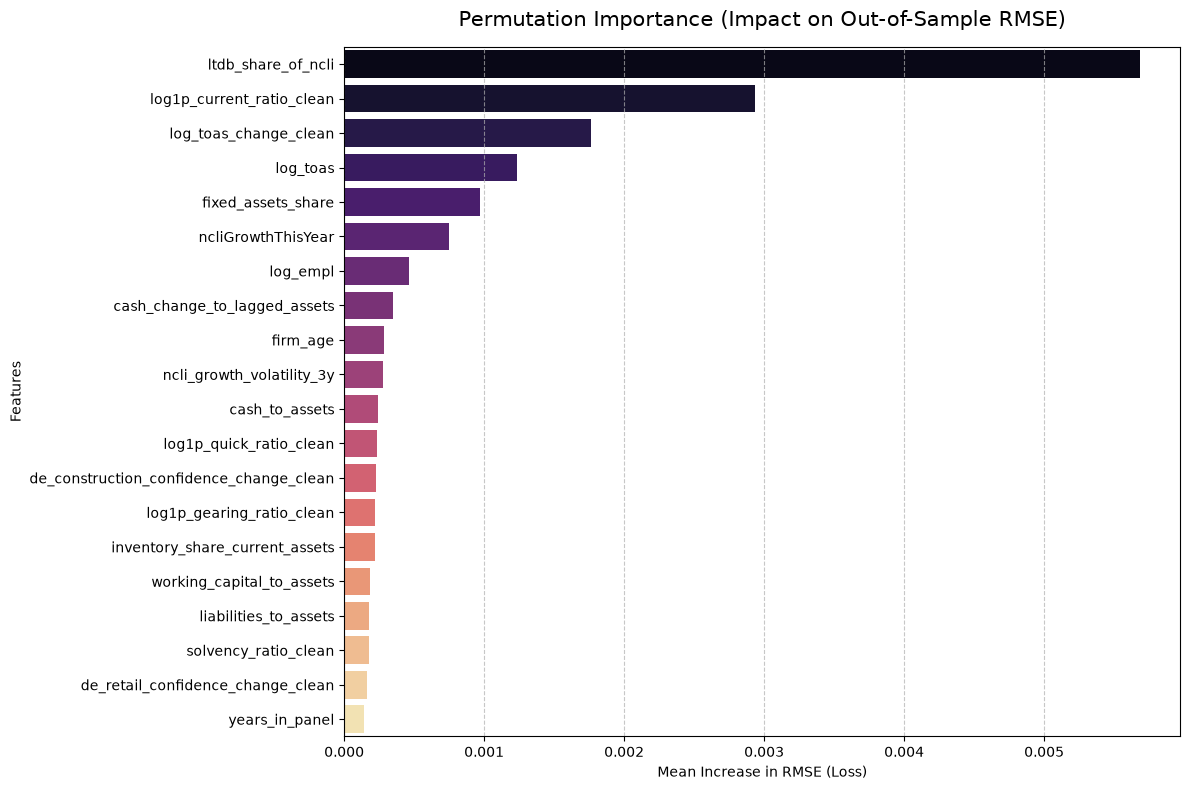

In [29]:
from sklearn.inspection import permutation_importance

# We shuffle each feature 5 times (n_repeats) and measure the drop in R2
perm_results = permutation_importance(
    final_trained_models["firm_survey_text"],            
    test_df[ALL_FEATURES],     
    test_df[TARGET].values, 
    n_repeats=5, 
    random_state=42, 
    scoring='neg_root_mean_squared_error',              
    n_jobs=2,
    max_samples=0.5  # Use 50% of the test set for faster computation
)

perm_df = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'Importance_Mean': perm_results.importances_mean,
    'Importance_Std': perm_results.importances_std
})

perm_df = perm_df.sort_values(by='Importance_Mean', ascending=False).reset_index(drop=True)

print("\nTop Features by Permutation Importance (RMSE Increase)")
print(perm_df.head(15).to_string(index=False))

# Plot the results
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importance_Mean', 
    y='Feature', 
    data=perm_df.head(20), 
    palette='magma'
)
plt.title('Permutation Importance (Impact on Out-of-Sample RMSE)', fontsize=15, pad=15)
plt.xlabel('Mean Increase in RMSE (Loss)')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()